In [65]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from csv_reader import read_csv
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
def plot_losses(data_paths, xlim=None):
    for dp in data_paths:
        fig, axs = plt.subplots(1, 1, figsize=(3, 2))
        o = read_csv(os.path.join('sims_out', dp, 'train_data.csv'), read_header=False)
        losses = np.array(o.iloc[:, 1])
        axs.scatter(np.arange(len(losses)), losses, s=1, c='black')
        axs.set_ylim(0, 10000)
        if xlim is not None:
            axs.set_xlim(*xlim)
        format_plot(axs)

In [106]:
data_paths = [
    '260ms_train_jax_no_noise_2D_inh_het_0p2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-10-02_17:47:37.306583_run_000221',
    '260ms_train_jax_no_noise_2D_inh_het_0p2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8016_2025-10-02_17:50:20.657556_run_000222',
    '260ms_train_jax_no_noise_2D_inh_het_0p2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8017_2025-10-02_18:13:34.573676_run_000223',
]

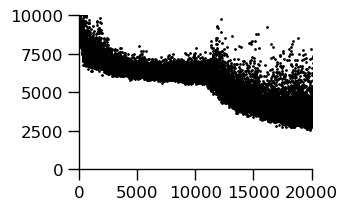

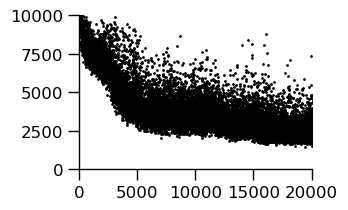

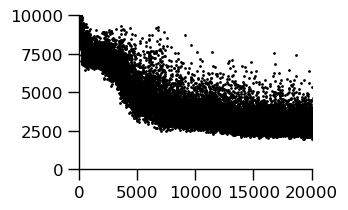

In [107]:
plot_losses(data_paths, xlim=(0, 20000))

In [12]:
data_paths = [
    '260ms_train_jax_no_noise_2D_inh_het_0p2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-10-02_17:47:37.306583_run_000221',
    '260ms_train_jax_no_noise_2D_inh_het_0p2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8016_2025-10-02_17:50:20.657556_run_000222',
    '260ms_train_jax_no_noise_2D_inh_het_0p2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8017_2025-10-02_18:13:34.573676_run_000223',
]

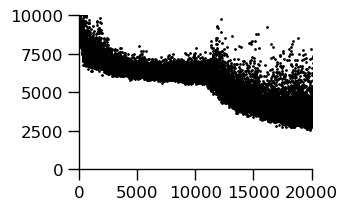

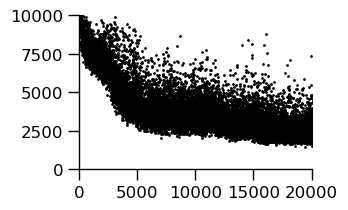

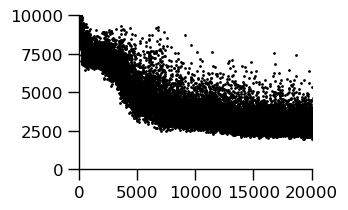

In [13]:
plot_losses(data_paths, xlim=(0, 20000))

In [38]:
data_paths = [
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-21_18:08:57.451744_run_000410',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-21_18:08:46.010920_run_000411',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-21_18:08:46.010929_run_000412',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-21_18:08:46.010922_run_000413',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-21_18:08:46.010901_run_000414',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-21_18:08:43.069202_run_000415',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-21_18:08:43.074084_run_000416',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-21_18:08:44.392073_run_000417',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-21_18:08:43.965204_run_000418',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-21_18:08:44.194421_run_000419',
]

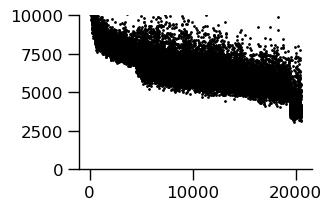

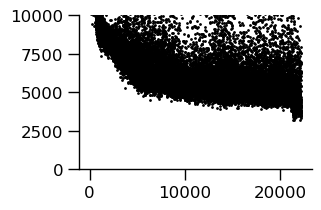

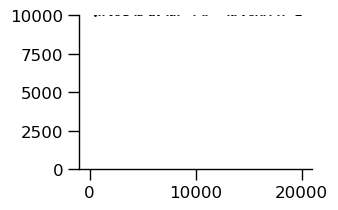

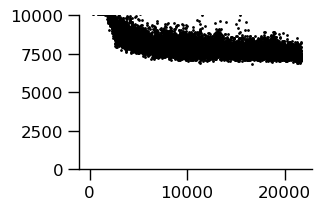

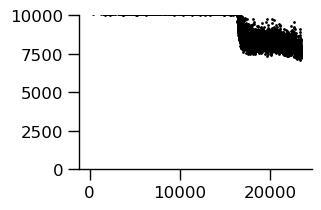

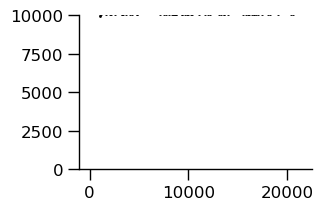

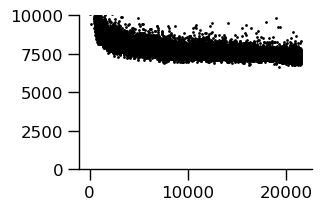

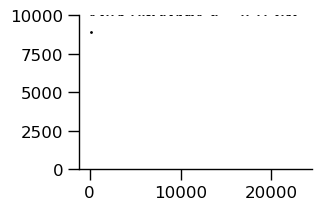

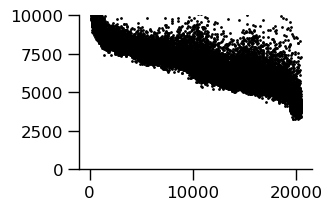

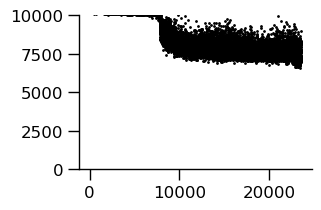

In [39]:
plot_losses(data_paths)

In [32]:
data_paths = [
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-21_18:31:16.544800_run_000430',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-21_18:31:17.012458_run_000431',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-21_18:31:17.327102_run_000432',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-21_18:31:16.555737_run_000433',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-21_18:31:46.842461_run_000434',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-21_18:31:46.867760_run_000435',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-21_18:31:36.135083_run_000436',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-21_18:31:35.674949_run_000437',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-21_18:31:35.232383_run_000438',
    '2d_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-21_18:31:37.935932_run_000439',
]

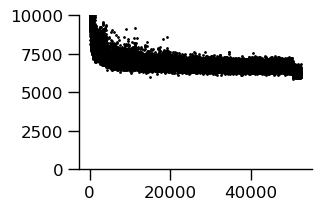

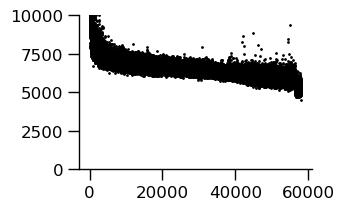

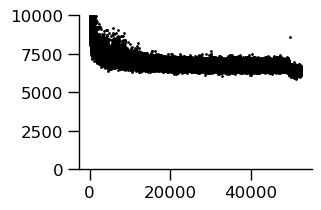

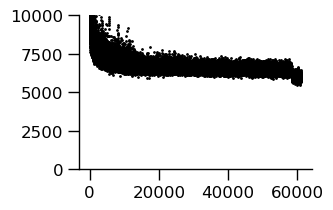

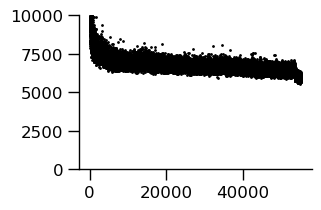

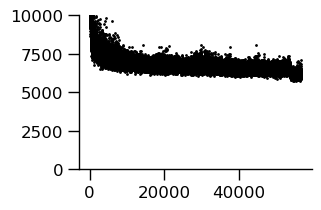

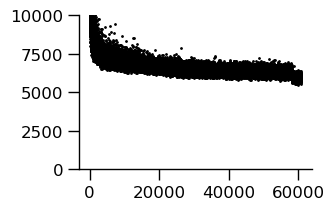

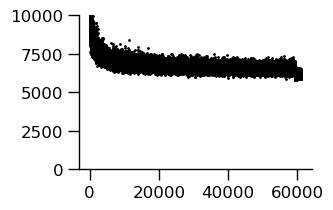

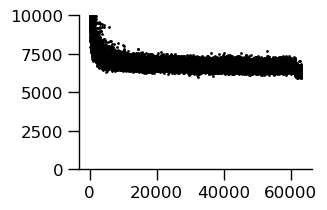

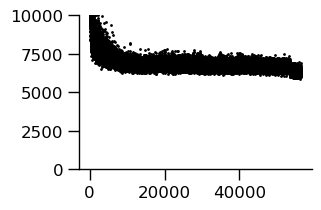

In [33]:
plot_losses(data_paths)

In [34]:
data_paths = [
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-21_18:31:37.935919_run_000440',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-21_18:31:36.191259_run_000441',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-21_18:31:36.537795_run_000442',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-21_18:31:36.537795_run_000443',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-21_18:31:36.537798_run_000444',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-21_18:31:37.966359_run_000445',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-21_18:31:37.966347_run_000446',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-21_18:31:37.013625_run_000447',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-21_18:31:37.013627_run_000448',
    '2d_time_1.0_inp_0.98_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-21_18:31:37.013628_run_000449',
]

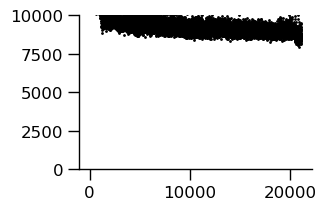

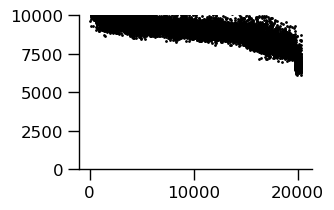

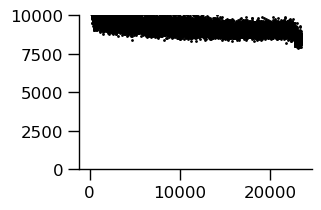

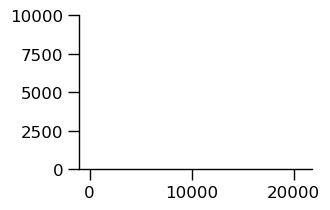

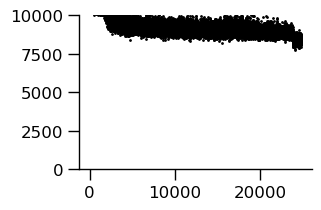

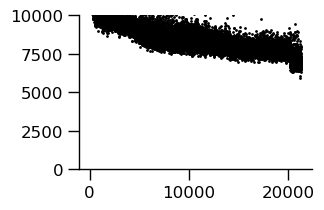

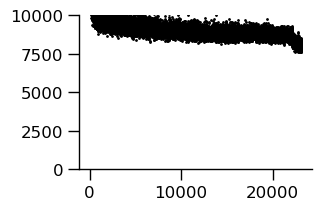

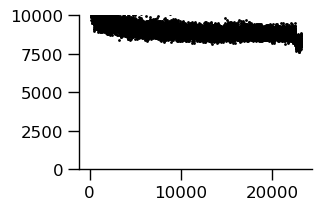

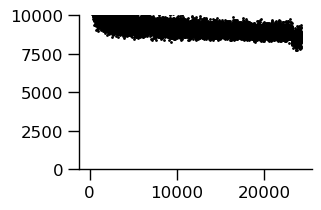

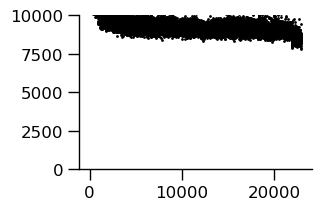

In [35]:
plot_losses(data_paths)

In [30]:
data_paths = [
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-22_12:40:55.922877_run_000450',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-22_12:40:58.814424_run_000451',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-22_12:40:55.406981_run_000452',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-22_12:40:55.357477_run_000453',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-22_12:42:01.104242_run_000454',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-22_12:41:55.089003_run_000455',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-22_12:42:52.242678_run_000456',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-22_12:42:52.304469_run_000457',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-22_12:43:12.268187_run_000458',
    '2d_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-22_12:44:16.957315_run_000459',
]

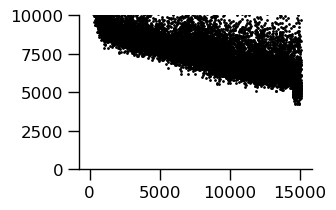

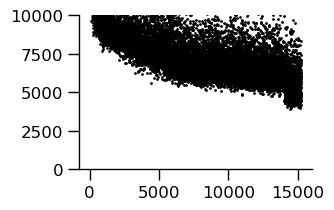

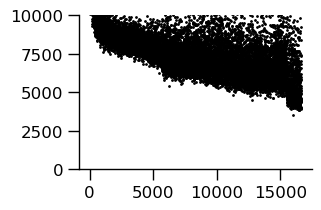

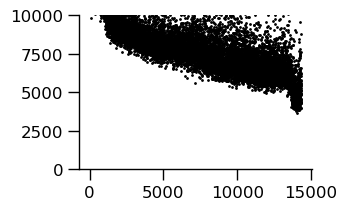

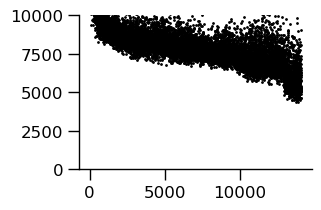

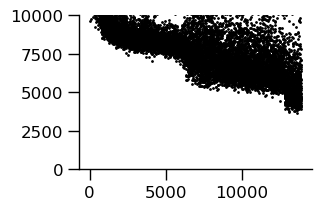

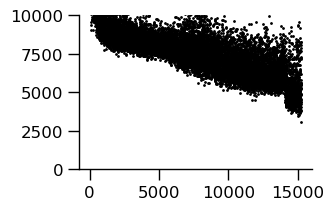

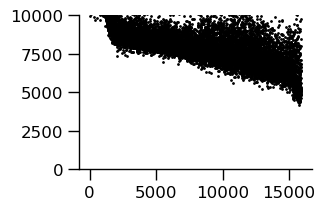

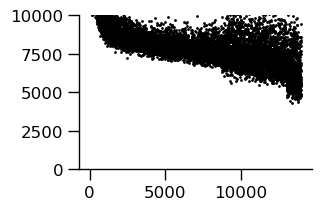

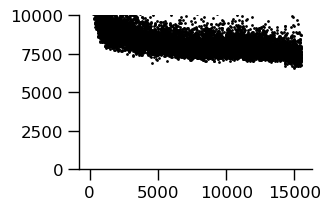

In [31]:
plot_losses(data_paths)

In [100]:
data_paths = [
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-23_21:43:36.419354_run_000460',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-23_21:43:36.381265_run_000461',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-23_21:43:45.234295_run_000462',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-23_21:43:42.287229_run_000463',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-23_21:43:43.555921_run_000464',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-23_21:43:43.214309_run_000465',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-23_21:43:42.400678_run_000466',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-23_21:43:41.582245_run_000467',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-23_21:43:39.249249_run_000468',
    '2D_short_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-23_21:43:39.547090_run_000469',
]

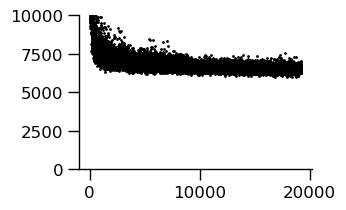

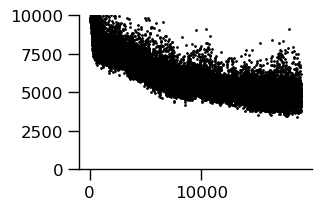

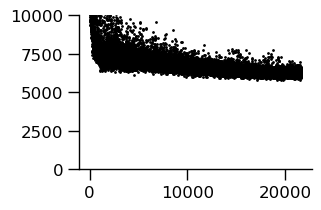

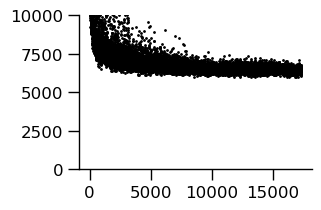

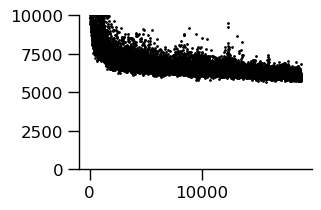

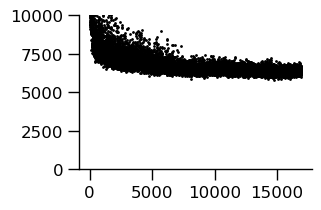

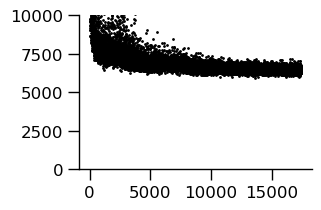

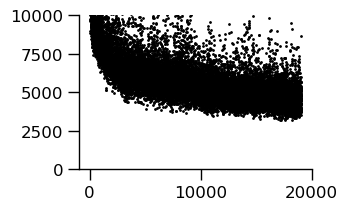

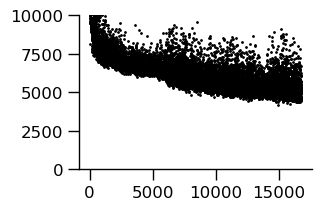

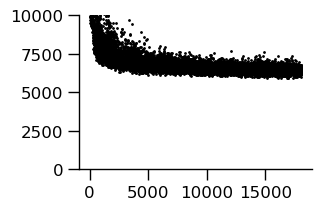

In [101]:
plot_losses(data_paths)

In [102]:
data_paths = [
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-23_22:25:03.185524_run_000480',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-23_22:25:09.743590_run_000481',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-23_22:26:05.809224_run_000482',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-23_22:26:06.718837_run_000483',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-23_22:27:05.095220_run_000484',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-23_22:28:07.540915_run_000485',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-23_22:29:05.562192_run_000486',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-23_22:29:39.208249_run_000487',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-23_22:30:00.301132_run_000488',
    '2d_normal_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-23_22:30:03.199009_run_000489',
]

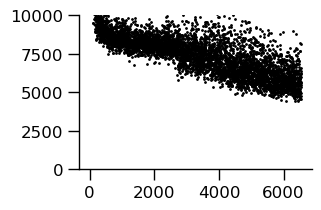

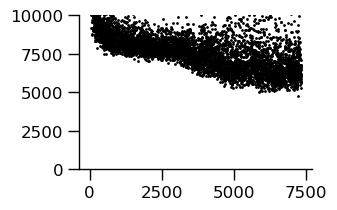

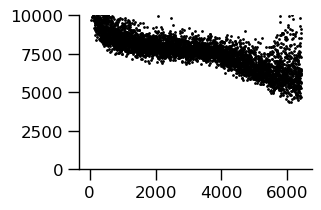

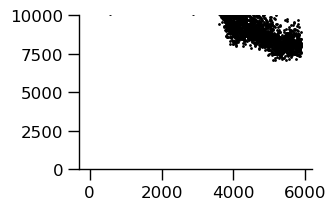

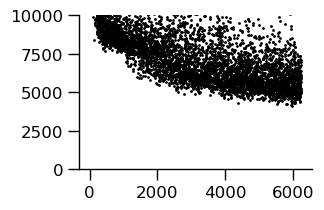

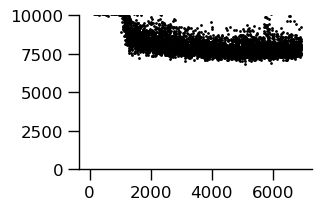

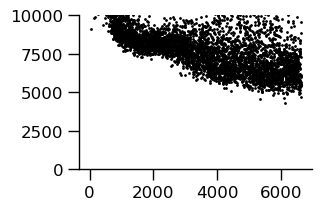

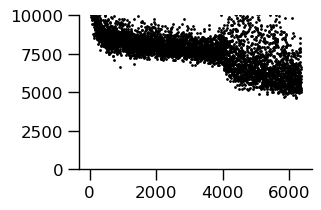

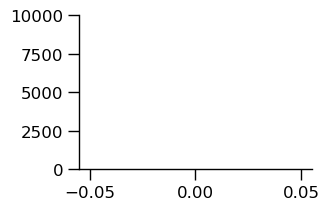

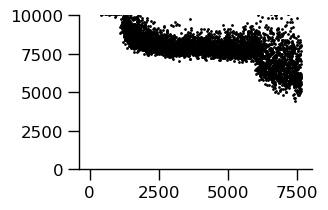

In [103]:
plot_losses(data_paths)

In [94]:
data_paths = [
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-23_22:30:39.121886_run_000490',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-23_22:30:39.121899_run_000491',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-23_22:30:39.121887_run_000492',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-23_22:30:39.121902_run_000493',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-23_22:30:39.121888_run_000494',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-23_22:30:46.133492_run_000495',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-23_22:30:46.133486_run_000496',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-23_22:30:46.133481_run_000497',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-23_22:30:46.133478_run_000498',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-23_22:30:46.133477_run_000499',
]

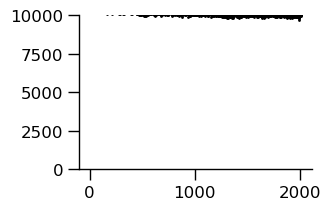

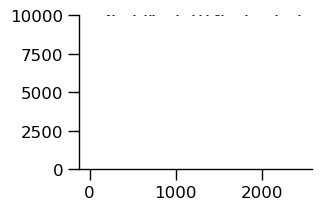

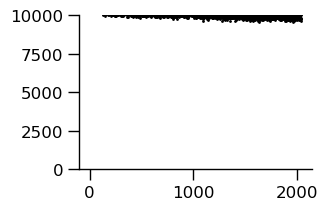

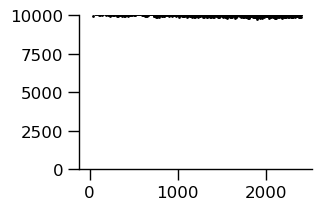

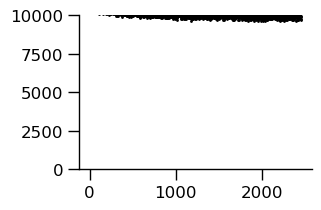

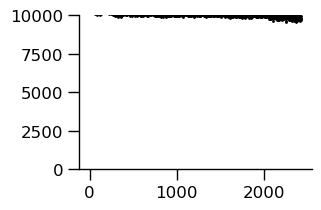

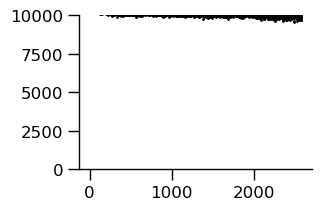

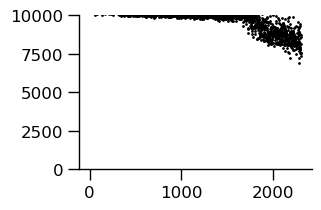

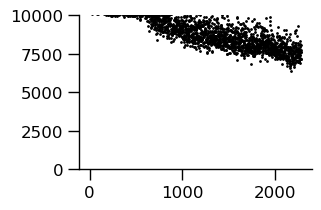

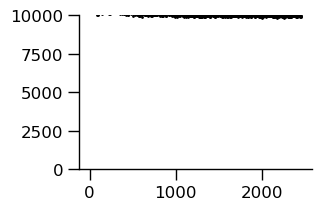

In [95]:
plot_losses(data_paths)

In [104]:
data_paths = [
    '2D_short_optim_cmaes_pop_size_30_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:45:37.466847_run_000500',
    '2D_short_optim_cmaes_pop_size_30_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:46:05.537572_run_000503',
    '2D_short_optim_cmaes_pop_size_30_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:46:04.545470_run_000506',
    '2D_short_optim_cmaes_pop_size_60_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:46:07.886653_run_000501',
    '2D_short_optim_cmaes_pop_size_60_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:46:02.707613_run_000504',
    '2D_short_optim_cmaes_pop_size_60_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:46:02.482033_run_000507',
    '2D_short_optim_cmaes_pop_size_90_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:46:05.537578_run_000502',
    '2D_short_optim_cmaes_pop_size_90_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:46:04.545479_run_000505',
    '2D_short_optim_cmaes_pop_size_90_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-24_12:45:57.734877_run_000508',
]

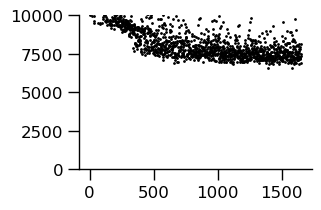

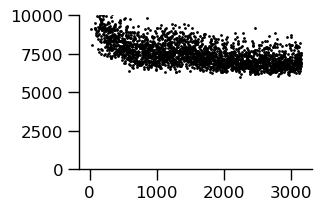

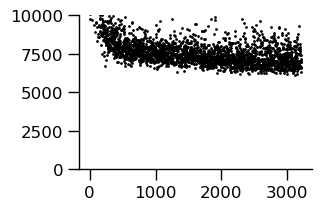

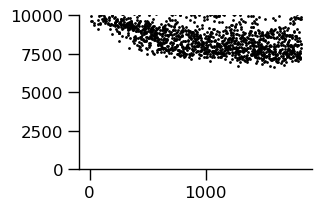

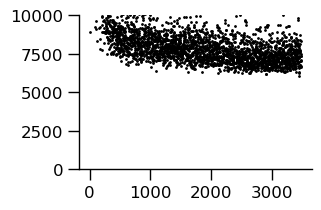

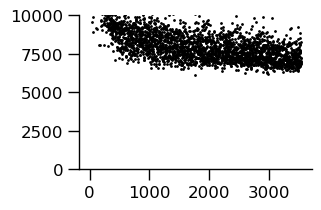

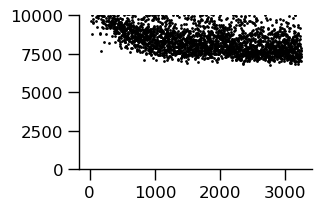

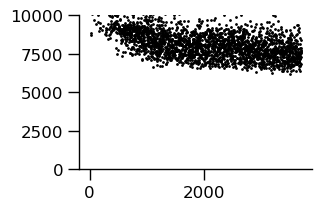

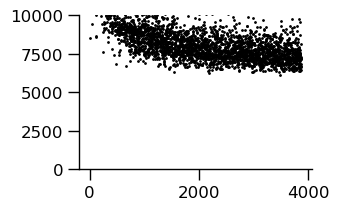

In [105]:
plot_losses(data_paths)